# 🌱 AI AgriYield Predictor
## Milestone 1: Requirements Analysis, Dataset Preparation & Exploratory Data Analysis
**Project Title:** AI-Based Crop Yield Prediction Using Soil and Weather Parameters  
**Author:** Maheshbharathi  
**Domain:** Agricultural Artificial Intelligence & Precision Farming  
---
### 📌 Objective
The objective of Milestone 1 is to ingest, clean, explore, and preprocess the agricultural dataset. We evaluate soil nutrients ($N, P, K$), environmental factors (rainfall, temperature, soil pH), crop varieties, and regional characteristics to prepare a standardized feature matrix for machine learning regression models.

### 1. Environment Setup & Library Initialization

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Visualization styling
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.sans-serif'] = 'Segoe UI', 'DejaVu Sans', 'Arial'
print("Libraries loaded successfully.")

Libraries loaded successfully.


### 2. Dataset Ingestion & Overview

In [13]:
dataset_path = '../dataset/dataset.csv'
df = pd.read_csv(dataset_path)
print(f"Dataset Loaded Successfully. Total Records: {df.shape[0]}, Total Features: {df.shape[1]}")
df.head()

Dataset Loaded Successfully. Total Records: 1500, Total Features: 12


,State,Crop,Soil_Type,Fertilizer,N,P,K,Rainfall_mm,Temperature_C,Yield_kg_per_acre,Soil_pH,Year
0,Karnataka,Soybean,Loamy,DAP,96,41,51,123,31.06,1899,6.82,2003
1,Odisha,Cotton,Red Soil,Urea,29,36,112,247,33.97,1002,6.41,2002
2,Punjab,Groundnut,Red Soil,Compost,37,38,177,142,24.21,1465,7.06,2015
3,Gujarat,Wheat,Red Soil,Compost,58,77,129,227,30.85,2273,5.93,2022
4,Andhra Pradesh,Cotton,Clay,Organic,108,61,63,263,37.81,1497,6.24,2017


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   State              1500 non-null   object 
 1   Crop               1500 non-null   object 
 2   Soil_Type          1500 non-null   object 
 3   Fertilizer         1500 non-null   object 
 4   N                  1500 non-null   int64  
 5   P                  1500 non-null   int64  
 6   K                  1500 non-null   int64  
 7   Rainfall_mm        1500 non-null   int64  
 8   Temperature_C      1500 non-null   float64
 9   Yield_kg_per_acre  1500 non-null   int64  
 10  Soil_pH            1500 non-null   float64
 11  Year               1500 non-null   int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 140.8+ KB


In [5]:
df.describe()

,N,P,K,Rainfall_mm,Temperature_C,Yield_kg_per_acre,Soil_pH,Year
count,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000
mean,75.213333,62.742667,101.707333,176.13200,27.862700,8995.054667,6.768160,2011.962667
std,37.664965,33.558355,54.762064,72.02378,5.598031,20115.157985,0.715777,7.341835
min,10.000000,5.000000,10.000000,50.00000,18.020000,539.000000,5.500000,2000.000000
25%,43.000000,33.000000,56.000000,115.00000,23.260000,1738.750000,6.150000,2006.000000
50%,77.000000,63.000000,97.000000,176.00000,27.895000,2612.000000,6.770000,2012.000000
75%,108.000000,92.000000,149.000000,238.00000,32.570000,4036.250000,7.390000,2018.000000
max,139.000000,119.000000,199.000000,299.00000,37.950000,88835.000000,8.000000,2024.000000


### 3. Data Cleaning & Integrity Verification

In [6]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per attribute:")
print(missing_values)

# Check for duplicate records
duplicate_count = df.duplicated().sum()
print(f"\nDuplicate rows detected: {duplicate_count}")

Missing values per attribute:
State                0
Crop                 0
Soil_Type            0
Fertilizer           0
N                    0
P                    0
K                    0
Rainfall_mm          0
Temperature_C        0
Yield_kg_per_acre    0
Soil_pH              0
Year                 0
dtype: int64

Duplicate rows detected: 0


### 4. Exploratory Data Analysis (EDA)
#### 4.1 Target Variable (Crop Yield) Distribution

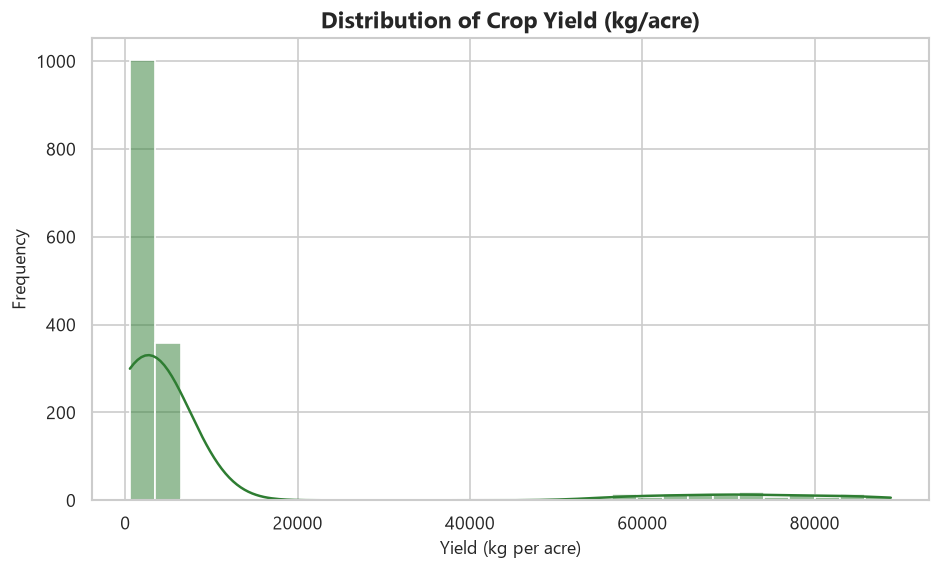

In [7]:
plt.figure(figsize=(9, 5), dpi=120)
sns.histplot(df['Yield_kg_per_acre'], bins=30, kde=True, color='#2E7D32')
plt.title('Distribution of Crop Yield (kg/acre)', fontsize=14, fontweight='bold')
plt.xlabel('Yield (kg per acre)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.show()

#### 4.2 Feature Correlation Matrix

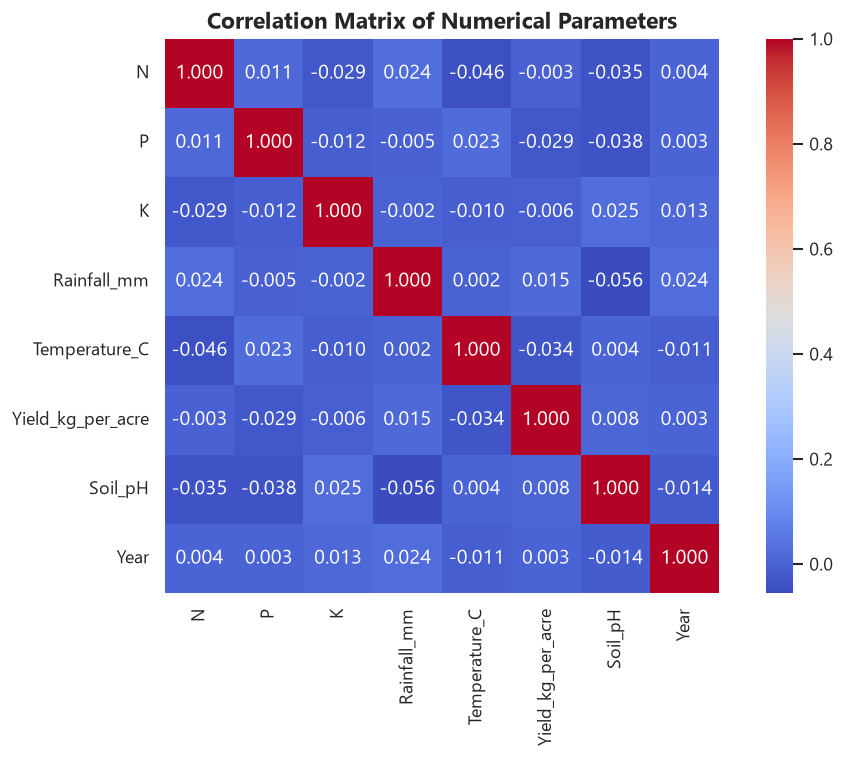

In [8]:
plt.figure(figsize=(10, 6), dpi=120)
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', cbar=True, square=True)
plt.title('Correlation Matrix of Numerical Parameters', fontsize=14, fontweight='bold')
plt.show()

#### 4.3 Crop-wise Yield Comparison

C:\Users\Maheshbharathi\AppData\Local\Temp\ipykernel_30656\2431861637.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Crop', y='Yield_kg_per_acre', palette='mako')


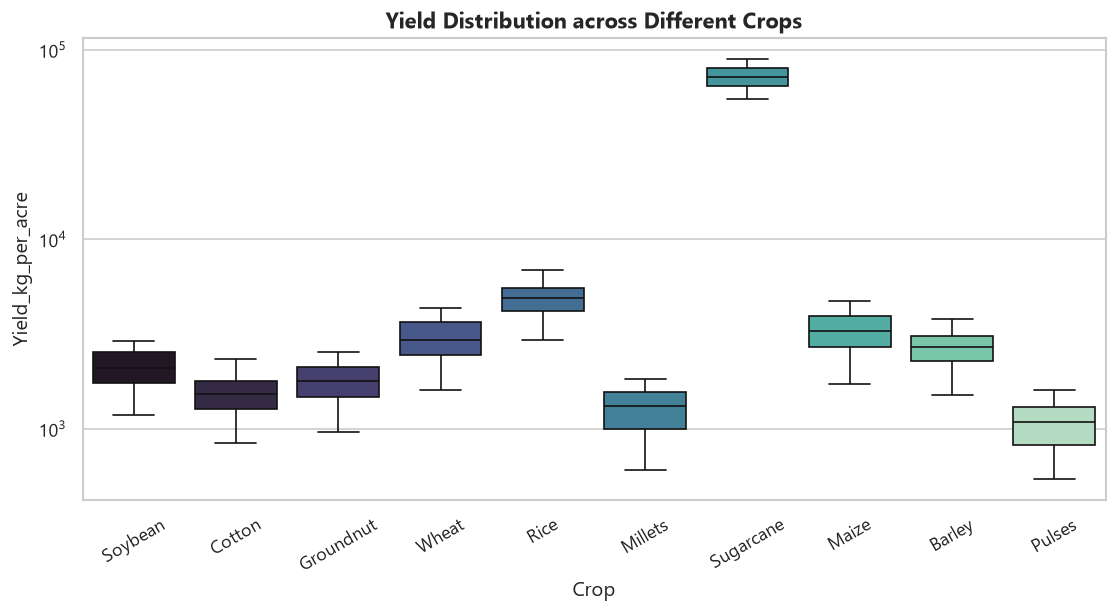

In [9]:
plt.figure(figsize=(11, 5), dpi=120)
sns.boxplot(data=df, x='Crop', y='Yield_kg_per_acre', palette='mako')
plt.title('Yield Distribution across Different Crops', fontsize=13, fontweight='bold')
plt.yscale('log')
plt.xticks(rotation=30)
plt.show()

### 5. Feature Engineering & Preprocessing
#### 5.1 One-Hot Encoding for Categorical Attributes

In [10]:
# Separate feature matrix X and target vector y
X = df.drop('Yield_kg_per_acre', axis=1)
y = df['Yield_kg_per_acre']

# One-Hot Encoding with drop_first=True
X_encoded = pd.get_dummies(X, drop_first=True)
print("Shape after One-Hot Encoding:", X_encoded.shape)

Shape after One-Hot Encoding: (1500, 39)


#### 5.2 Feature Standardization using StandardScaler

In [11]:
scaler = StandardScaler()
numerical_features = ['N', 'P', 'K', 'Rainfall_mm', 'Temperature_C', 'Soil_pH', 'Year']

X_encoded[numerical_features] = scaler.fit_transform(X_encoded[numerical_features])
print("Final preprocessed feature matrix shape:", X_encoded.shape)
X_encoded.head()

Final preprocessed feature matrix shape: (1500, 39)


,N,P,K,Rainfall_mm,Temperature_C,Soil_pH,Year,State_Bihar,State_Gujarat,State_Haryana,...,Crop_Wheat,Soil_Type_Black Soil,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Red Soil,Soil_Type_Sandy,Fertilizer_DAP,Fertilizer_NPK,Fertilizer_Organic,Fertilizer_Urea
0,0.552067,-0.648122,-0.926266,-0.737947,0.571338,0.072449,-1.221174,False,False,False,...,False,False,False,True,False,False,True,False,False,False
1,-1.227367,-0.797166,0.188015,0.984281,1.091337,-0.500546,-1.357425,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,-1.014897,-0.737549,1.375364,-0.474057,-0.652715,0.407861,0.413840,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,-0.457164,0.424994,0.498553,0.706502,0.533812,-1.171370,1.367598,False,True,False,...,True,False,False,False,True,False,False,False,False,False
4,0.870772,-0.051947,-0.707063,1.206504,1.777521,-0.738130,0.686342,False,False,False,...,False,False,True,False,False,False,False,False,True,False


### 6. Summary & Conclusion
Milestone 1 data pipeline successfully completed:
- Dataset ingested and verified (1,500 samples, 12 features).
- No missing values or duplicates detected.
- Exploratory analysis visualised key distributions and relationships.
- Categorical features encoded and numerical features scaled to mean 0, std 1.
- Final feature matrix of shape (1500, 39) prepared for Milestone 2 regression modeling.